# The style duel

Built from [`STYLE_DUEL.md`](../STYLE_DUEL.md), the complete design specification for this visual.

This notebook loads the artifacts already computed by [`hansard-pm-nlp`](https://github.com/RedaAllab/hansard-pm-nlp) (Phases 3, 4 and 6: `eda_summary.csv`, `affect_summary.csv`, `phase6_*`), without re-running any `build_*.py` script from that repo, and produces the 3 images in `portfolio/01_style_duel/assets/`:

1. `radar_main.png`: the main radar (6 stylometric traits x 4 Prime Ministers)
2. `feature_importance.png`: why these traits matter (permutation importance, Phase 6)
3. `confusion_matrix.png`: does the classifier find the right Prime Minister?

Prerequisite: `hansard-pm-nlp` cloned as a sibling directory (`../hansard-pm-nlp`) or `HANSARD_PM_NLP_DIR` pointing at it, see this repo's root README.

In [1]:
from pathlib import Path

from hansard_pm_portfolio import data_access as da
from hansard_pm_portfolio.viz import style_duel as viz

ASSETS_DIR = Path("../portfolio/01_style_duel/assets")
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

## 0. README banner

In [2]:
fig = viz.plot_banner("The style duel", "hansard-pm-portfolio, project 01")
viz.save(fig, ASSETS_DIR / "banner.png")
fig

<Figure size 800x200 with 0 Axes>

<Figure size 800x200 with 0 Axes>

## 1. Stylometric profile: the radar

5 of the 6 axes come directly from `hansard-pm-nlp`'s Phase 3/4 exports (`eda_summary.csv`, `affect_summary.csv`), the same two files the live dashboard's "Stylometric profile by PM" tab merges. The 6th (`fw_not_rate`, frequency of the word "not") is recomputed here with the same pure regex tokenizer as `hansard_pm_nlp.lexical.tokenize_words` (no heavy dependency added), because Phase 6 only exported it for 3 of the 4 Prime Ministers (Truss excluded from the classifier). See `ARCHITECTURE.md` for the full rationale, including the substitution of `pos_INTJ` (the original spec's choice) with `mean_words_per_sentence`.

In [3]:
profile = da.load_style_profile()
profile[["pm_name", "n_contributions"] + [c for c, _ in da.RADAR_AXES]]

,pm_name,n_contributions,mtld,mean_flesch_kincaid_grade,mean_hedge_rate,mean_net_certainty,fw_not_rate,mean_words_per_sentence
0,Boris Johnson,5459,76.797033,9.423627,0.011333,0.005059,0.005349,19.693269
1,Keir Starmer,2896,77.742498,8.956253,0.007267,0.008541,0.006298,18.078021
2,Liz Truss,123,76.378099,9.424829,0.004625,0.015994,0.006673,18.172306
3,Rishi Sunak,2195,87.367750,10.738651,0.006038,0.007699,0.004794,20.937373


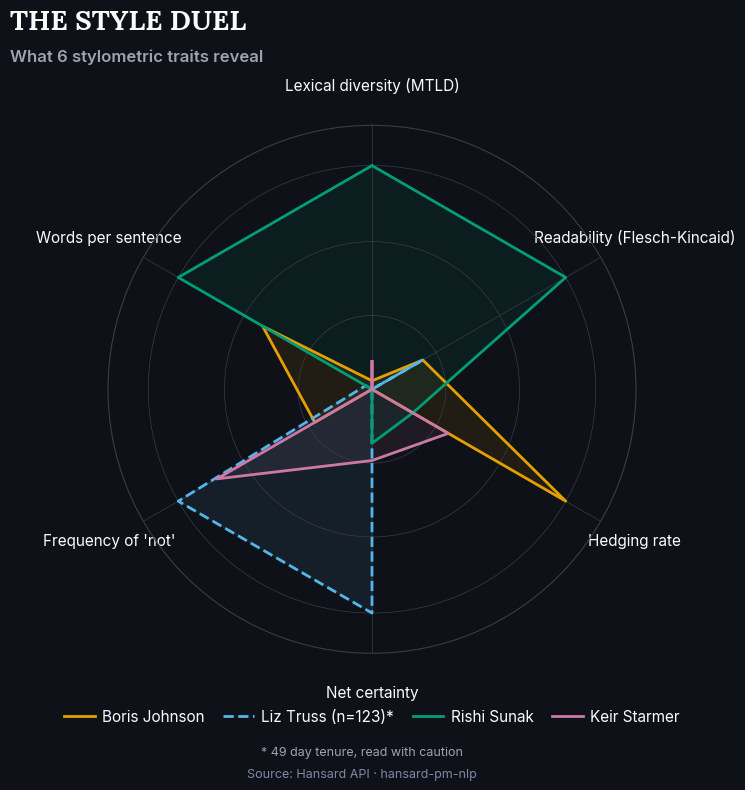

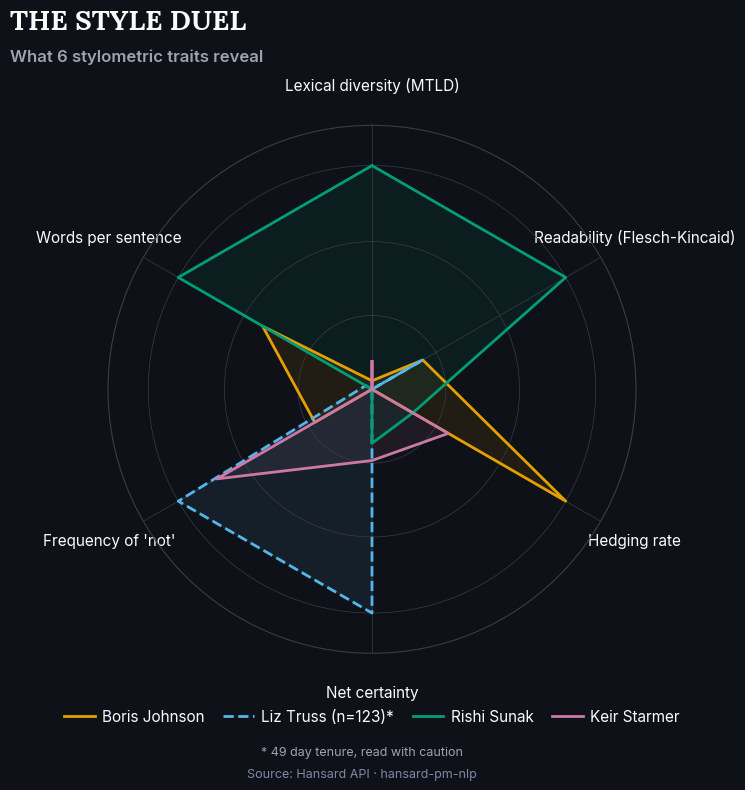

In [4]:
fig = viz.plot_style_radar(profile)
viz.save(fig, ASSETS_DIR / "radar_main.png")
fig

## 2. Why these traits matter: permutation importance

Phase 6 exports the top 15 (per model) permutation importances computed on the test set (`phase6_feature_importance_hgb.csv`, `phase6_feature_importance_logreg.csv`). The top 6 of the more accurate model (HistGradientBoosting, 93.2% accuracy) is used here, not necessarily the exact 6 radar traits above: `flesch_kincaid` and `fw_not` do not appear in either model's top 15, so no permutation importance value exists for them. 3 of the radar's 6 traits (`mtld`, `hedge_rate`, `mean_words_per_sentence`) do overlap with this top 6.

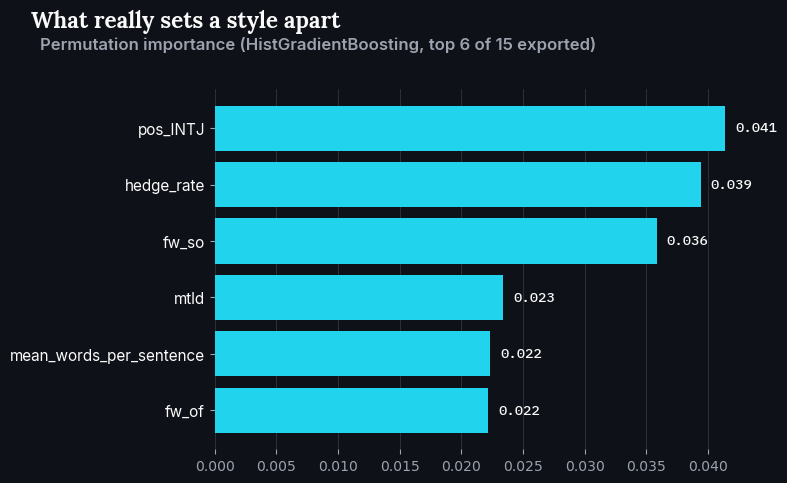

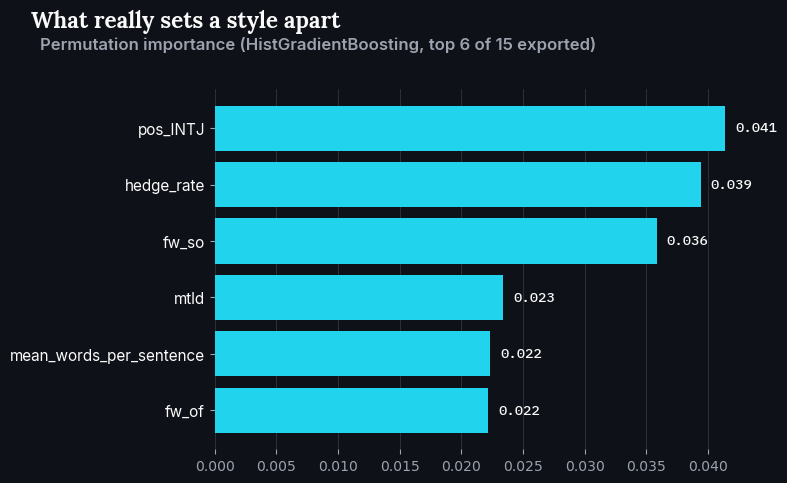

In [5]:
importance = da.load_feature_importance("hgb").head(6).sort_values("importance")
fig = viz.plot_feature_importance_bar(
    importance,
    "What really sets a style apart",
    "Permutation importance (HistGradientBoosting, top 6 of 15 exported)",
)
viz.save(fig, ASSETS_DIR / "feature_importance.png")
fig

## 3. Does the classifier find the right Prime Minister?

3 classes (Boris Johnson, Rishi Sunak, Keir Starmer). Liz Truss is excluded by Phase 6 itself (5 documents, 49 day tenure, too few for a reliable train/test split; see `hansard-pm-nlp/src/hansard_pm_nlp/split.py`). Matrix normalized by row (percent of each actual PM's test sittings).

In [6]:
predictions = da.load_test_predictions()
metrics = da.load_classifier_metrics()
hgb_accuracy = metrics.set_index("model").loc["hgb", "accuracy"]
matrix = da.build_confusion_matrix(predictions, "pred_hgb")
matrix.round(1)

pred_hgb,Boris Johnson,Rishi Sunak,Keir Starmer
pm_name,,,
Boris Johnson,93.1,6.9,0.0
Rishi Sunak,0.0,92.3,7.7
Keir Starmer,5.9,0.0,94.1


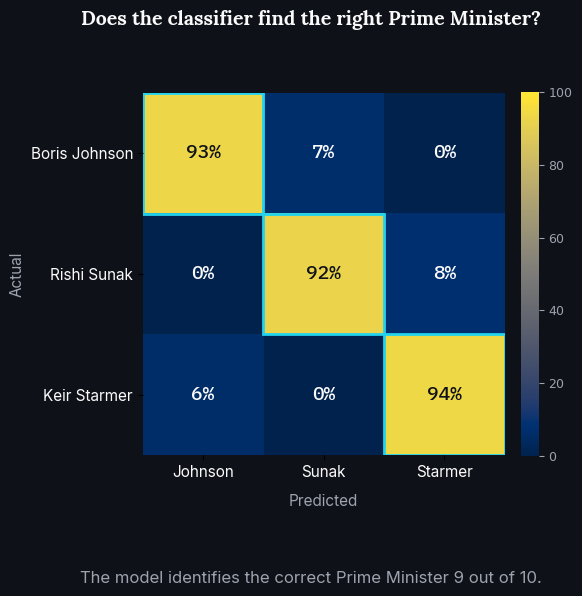

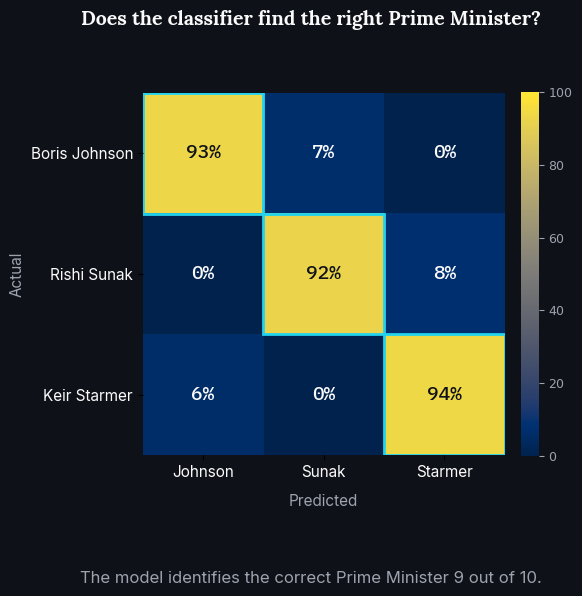

In [7]:
fig = viz.plot_confusion_matrix(matrix, hgb_accuracy)
viz.save(fig, ASSETS_DIR / "confusion_matrix.png")
fig

## Links

- Full specification: [`STYLE_DUEL.md`](../STYLE_DUEL.md)
- Classifier source report: [`phase6_classifier_report.md`](https://github.com/RedaAllab/hansard-pm-nlp/blob/main/data/processed/phase6_classifier_report.md) (in `hansard-pm-nlp`)
- Interactive dashboard: see `hansard-pm-nlp`'s root README
- This project's README: [`portfolio/01_style_duel/README.md`](../portfolio/01_style_duel/README.md)